# Resolution sweep on a collaboration network

How many communities does modularity maximisation find, and how large are they,
as the resolution `gamma` is swept from 0 to 1?

The network is [ca-CondMat](graphs/ca-CondMat.mtx): condensed-matter authors on
arXiv, joined when they co-authored a paper. Louvain is run at every resolution
for 10 seeds, so each point carries the spread over seeds rather than a single
run.

The sweep itself lives in [`src/resolution_sweep.py`](src/resolution_sweep.py).

`ResolutionSweep` holds the graph, the resolution grid, the seeds and the
community-detection methods, and runs every (method, gamma, seed) combination in
parallel.

`stats_path` is both the input and the output: `run()` reads the combinations
already stored in that CSV, computes only the missing ones and writes the merged
table back. Re-executing the notebook therefore costs nothing, and widening
`GAMMAS` or `SEEDS` only pays for the new points. Pass `reuse=False` to recompute
the whole grid. Every figure is drawn from that same table.

## 1. The network

The Matrix Market file is read into an undirected graph; edge weights are
dropped, only co-authorship is kept.

In [2]:
import random

import networkx as nx
import numpy as np
from scipy.io import mmread

from src.resolution_sweep import ResolutionSweep

GRAPH_PATH = "graphs/ca-CondMat.mtx"
GAMMAS = np.round(np.arange(0.0, 1.0001, 0.01), 2)      # resolution grid
SEEDS = random.Random(0).sample(range(1_000_000), 10)   # drawn once, reused at every gamma
STATS_CSV = "nc_gamma_stats_condmat.csv"

G = nx.from_scipy_sparse_array(mmread(GRAPH_PATH), create_using=nx.Graph())
print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")

/tmp/ipykernel_761002/4166458602.py:14: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  G = nx.from_scipy_sparse_array(mmread(GRAPH_PATH), create_using=nx.Graph())


Number of nodes: 21,363
Number of edges: 91,286


## 2. Running the sweep

`pending()` reports what is still missing before anything is computed, so a
resumed run shows how much work is left.

In [3]:
sweep = ResolutionSweep(G, GAMMAS, SEEDS, [nx.community.louvain_communities],
                        stats_path=STATS_CSV)
print({m: len(p) for m, p in sweep.pending().items()}, "combinations to compute")

stats = sweep.run()
stats.head()

{'louvain_communities': 0} combinations to compute


,method,gamma,seed,n_communities,b_p,mean_size
0,louvain_communities,0.0,42450,1,1.0,21363.0
1,louvain_communities,0.0,271493,1,1.0,21363.0
2,louvain_communities,0.0,403958,1,1.0,21363.0
3,louvain_communities,0.0,424604,1,1.0,21363.0
4,louvain_communities,0.0,441001,1,1.0,21363.0


## 3. Communities against resolution

`n_c` grows with `gamma`: the null term gets more expensive, so merging stops
paying off and the partition breaks into smaller pieces. Error bars are the
spread over the 10 seeds.

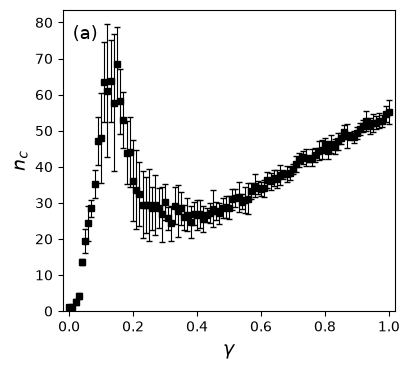

In [4]:
sweep.plot_n_communities(save="nc_vs_gamma_condmat.png");

## 4. Communities and null weight side by side

`b_p = sum_g (K_g / 2M)^2` is the null-model weight of the partition. It falls
from 1 to near 0 as the communities shrink, and reading it next to `n_c` shows
the same transition from the other side.

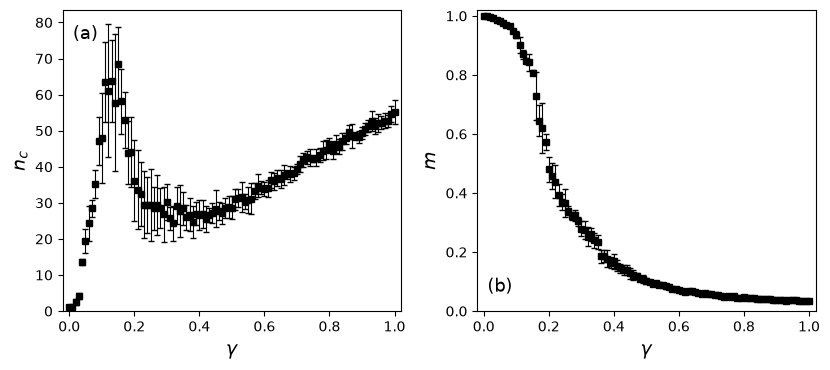

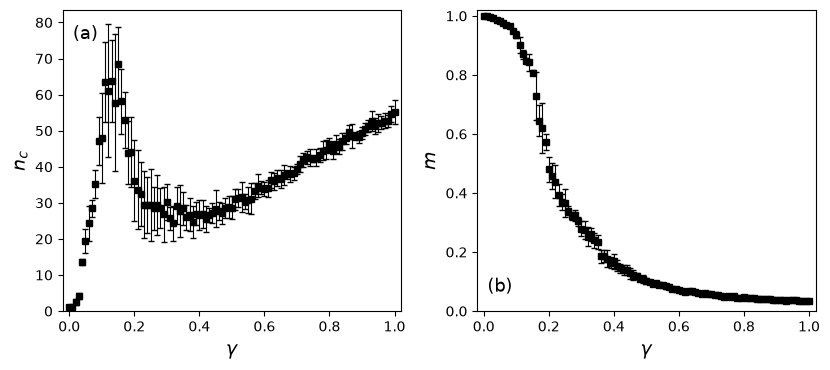

In [5]:
sweep.plot_n_communities_mod_regularizer(save="nc_bp_vs_gamma_condmat.png")